# Profiler View v2

Analisis comparativo simplificado de recursos.

- Fuente principal: `profiler_runs_summary_core.csv`.
- Foco: memoria por fase/dispositivo con dos lecturas:
  - `delta live`: cuanto sube memoria activa dentro de cada fase.
  - `alloc/free traffic`: actividad real del allocator dentro de cada fase.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.frameon": False,
    "grid.alpha": 0.18,
})

PALETTE = {False: "#1f77b4", True: "#ff7f0e"}
AMP_LABELS = {False: "FP32", True: "AMP"}
PHASE_COLORS = {
    "train_forward": "#1f77b4",
    "train_backward": "#ff7f0e",
    "train_step": "#2ca02c",
}


In [26]:
csv_path = Path("profiler_runs_summary_core.csv")
if not csv_path.exists():
    raise FileNotFoundError(
        "No existe profiler_runs_summary_core.csv. "
        "Ejecuta en 3_profiler.ipynb las celdas de collect_saved_runs + to_csv."
    )

df = pd.read_csv(csv_path)
print(f"CSV: {csv_path}")
print(f"rows={len(df)} cols={len(df.columns)}")


CSV: profiler_runs_summary_core.csv
rows=42 cols=54


In [27]:
num_cols = [
    "timesteps", "batch_size", "oom_events", "trace_size_mb",
    "train_batch_ms", "train_forward_ms", "train_backward_ms", "train_step_ms",
    "eval_no_f1_ms", "eval_with_f1_ms",
    "max_alloc_gb_trace", "max_reserved_gb_trace",
    "cpu_op_ms_trace", "gpu_total_ms_trace",
    "train_forward_alloc_delta_avg_mb_gpu", "train_forward_alloc_delta_peak_mb_gpu",
    "train_backward_alloc_delta_avg_mb_gpu", "train_backward_alloc_delta_peak_mb_gpu",
    "train_step_alloc_delta_avg_mb_gpu", "train_step_alloc_delta_peak_mb_gpu",
    "train_forward_alloc_delta_avg_mb_cpu", "train_forward_alloc_delta_peak_mb_cpu",
    "train_backward_alloc_delta_avg_mb_cpu", "train_backward_alloc_delta_peak_mb_cpu",
    "train_step_alloc_delta_avg_mb_cpu", "train_step_alloc_delta_peak_mb_cpu",
    "train_forward_alloc_traffic_mb_gpu", "train_forward_free_traffic_mb_gpu",
    "train_backward_alloc_traffic_mb_gpu", "train_backward_free_traffic_mb_gpu",
    "train_step_alloc_traffic_mb_gpu", "train_step_free_traffic_mb_gpu",
    "train_forward_alloc_traffic_mb_cpu", "train_forward_free_traffic_mb_cpu",
    "train_backward_alloc_traffic_mb_cpu", "train_backward_free_traffic_mb_cpu",
    "train_step_alloc_traffic_mb_cpu", "train_step_free_traffic_mb_cpu",
]
for c in num_cols:
    if c not in df.columns:
        df[c] = np.nan
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["use_amp"] = (
    df["use_amp"].astype(str).str.strip().str.lower().map({"true": True, "false": False})
)
df["is_oom"] = df["oom_events"].fillna(0) > 0

def ms_to_s(s):
    return s / 1000.0

for src, dst in [
    ("train_batch_ms", "train_batch_s"),
    ("train_forward_ms", "train_forward_s"),
    ("train_backward_ms", "train_backward_s"),
    ("train_step_ms", "train_step_s"),
    ("eval_no_f1_ms", "eval_no_f1_s"),
    ("eval_with_f1_ms", "eval_with_f1_s"),
    ("cpu_op_ms_trace", "cpu_op_s_trace"),
    ("gpu_total_ms_trace", "gpu_total_s_trace"),
]:
    df[dst] = ms_to_s(df[src])

df["eval_f1_overhead_pct"] = 100.0 * (df["eval_with_f1_s"] - df["eval_no_f1_s"]) / df["eval_no_f1_s"]
df["eval_f1_overhead_pct"] = df["eval_f1_overhead_pct"].replace([np.inf, -np.inf], np.nan)

df = df.sort_values(["timesteps", "use_amp"], na_position="last").reset_index(drop=True)

print(df[["run_name", "timesteps", "use_amp", "status", "oom_events"]].head(8))


                  run_name  timesteps  use_amp   status  oom_events
0   sim90_bs4_pb4_5ts_fp32          5    False       ok         0.0
1    sim90_bs4_pb4_5ts_amp          5     True       ok         0.0
2       sim90_bs4_pb4_10ts         10    False  unknown         0.0
3  sim90_bs4_pb4_10ts_fp32         10    False       ok         0.0
4   sim90_bs4_pb4_10ts_amp         10     True       ok         0.0
5  sim90_bs4_pb4_15ts_fp32         15    False       ok         0.0
6   sim90_bs4_pb4_15ts_amp         15     True       ok         0.0
7       sim90_bs4_pb4_25ts         25    False  unknown         0.0


## Seccion 1 - Global


In [28]:
A5000_GB = 23.68
GUIDES = [
    (0.80 * A5000_GB, "80%"),
    (0.85 * A5000_GB, "85%"),
    (0.90 * A5000_GB, "90%"),
    (1.00 * A5000_GB, "100%"),
]

def relabel_amp_legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    mapped = [AMP_LABELS.get(l == "True", l) if l in ["True", "False"] else l for l in labels]
    if handles:
        ax.legend(handles, mapped, loc="best")

def add_a5000_guides(ax):
    for y, tag in GUIDES:
        ax.axhline(y=y, linestyle="--", linewidth=1.0, color="#6b7280", alpha=0.7)
        ax.text(0.99, y, f" {tag} ({y:.2f} GB)", transform=ax.get_yaxis_transform(),
                ha="right", va="bottom", fontsize=8, color="#4b5563")


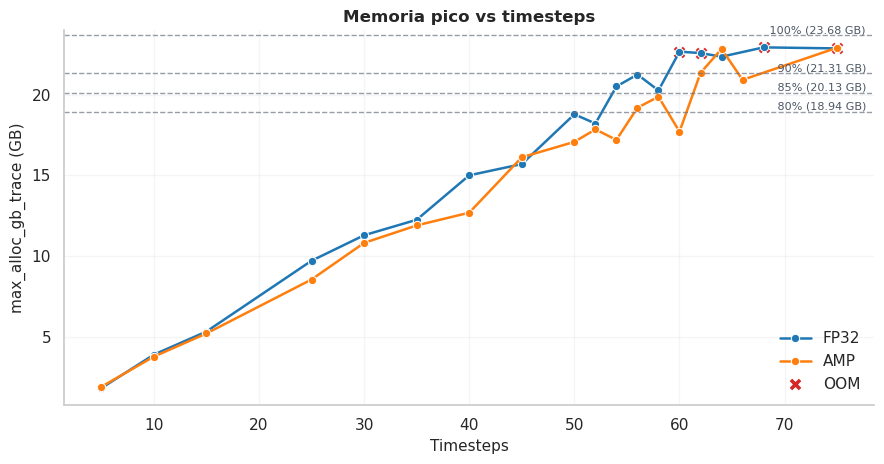

In [29]:
mem_df = df.dropna(subset=["timesteps", "max_alloc_gb_trace", "use_amp"]).copy()
fig, ax = plt.subplots(figsize=(9, 4.8))

sns.lineplot(
    data=mem_df,
    x="timesteps",
    y="max_alloc_gb_trace",
    hue="use_amp",
    palette=PALETTE,
    marker="o",
    linewidth=1.8,
    ax=ax,
)

oom_df = mem_df[mem_df["is_oom"]]
if len(oom_df):
    sns.scatterplot(data=oom_df, x="timesteps", y="max_alloc_gb_trace", color="#d62728", marker="X", s=90, label="OOM", ax=ax)

add_a5000_guides(ax)
relabel_amp_legend(ax)
ax.set_title("Memoria pico vs timesteps")
ax.set_xlabel("Timesteps")
ax.set_ylabel("max_alloc_gb_trace (GB)")
plt.tight_layout()
plt.show()


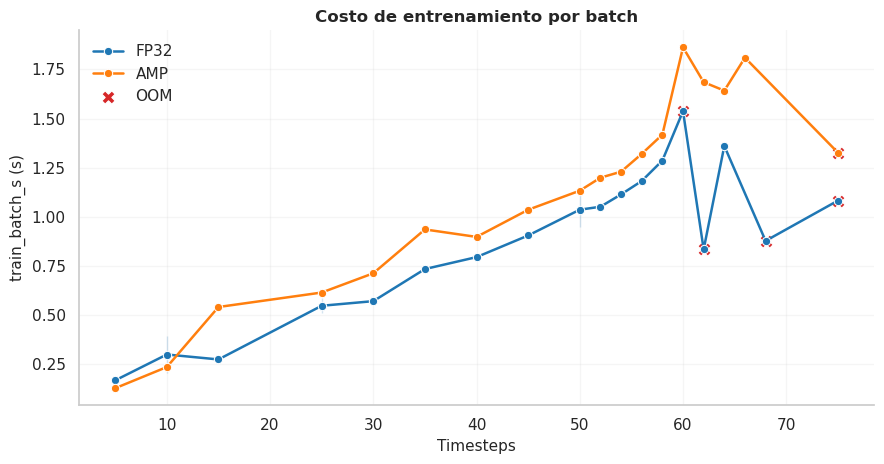

In [30]:
train_df = df.dropna(subset=["timesteps", "train_batch_s", "use_amp"]).copy()
fig, ax = plt.subplots(figsize=(9, 4.8))

sns.lineplot(data=train_df, x="timesteps", y="train_batch_s", hue="use_amp", palette=PALETTE, marker="o", linewidth=1.8, ax=ax)

oom_df = train_df[train_df["is_oom"]]
if len(oom_df):
    sns.scatterplot(data=oom_df, x="timesteps", y="train_batch_s", color="#d62728", marker="X", s=90, label="OOM", ax=ax)

relabel_amp_legend(ax)
ax.set_title("Costo de entrenamiento por batch")
ax.set_xlabel("Timesteps")
ax.set_ylabel("train_batch_s (s)")
plt.tight_layout()
plt.show()


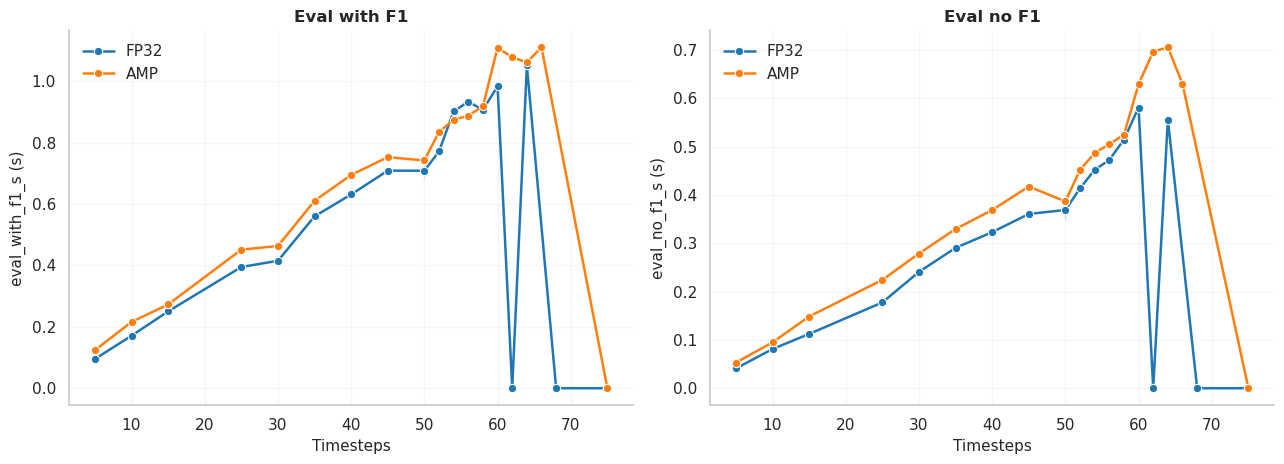

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)

eval_with_df = df.dropna(subset=["timesteps", "eval_with_f1_s", "use_amp"])
sns.lineplot(data=eval_with_df, x="timesteps", y="eval_with_f1_s", hue="use_amp", palette=PALETTE, marker="o", linewidth=1.8, ax=axes[0])
relabel_amp_legend(axes[0])
axes[0].set_title("Eval with F1")
axes[0].set_xlabel("Timesteps")
axes[0].set_ylabel("eval_with_f1_s (s)")

if df["eval_no_f1_s"].notna().any():
    eval_no_df = df.dropna(subset=["timesteps", "eval_no_f1_s", "use_amp"])
    sns.lineplot(data=eval_no_df, x="timesteps", y="eval_no_f1_s", hue="use_amp", palette=PALETTE, marker="o", linewidth=1.8, ax=axes[1])
    relabel_amp_legend(axes[1])
    axes[1].set_title("Eval no F1")
    axes[1].set_xlabel("Timesteps")
    axes[1].set_ylabel("eval_no_f1_s (s)")
else:
    axes[1].text(0.5, 0.5, "No eval_no_f1_s data", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


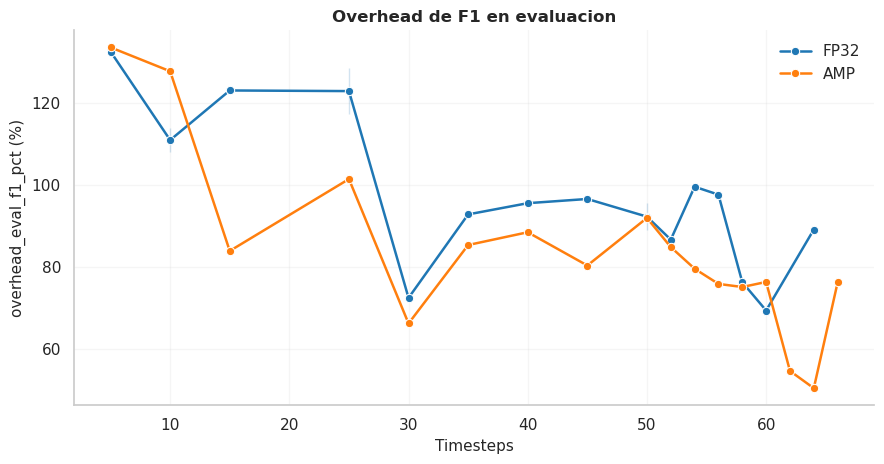

In [32]:
over_df = df.dropna(subset=["timesteps", "eval_f1_overhead_pct", "use_amp"])
if len(over_df):
    fig, ax = plt.subplots(figsize=(9, 4.8))
    sns.lineplot(data=over_df, x="timesteps", y="eval_f1_overhead_pct", hue="use_amp", palette=PALETTE, marker="o", linewidth=1.8, ax=ax)
    relabel_amp_legend(ax)
    ax.set_title("Overhead de F1 en evaluacion")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("overhead_eval_f1_pct (%)")
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos validos para overhead_eval_f1_pct")


## Seccion 2 - Memoria por Fase (comparativo real)

Interpretacion:
- `delta live`: subida de memoria activa dentro de la fase.
- `alloc/free traffic`: MB asignados/liberados en la fase (actividad real del allocator).


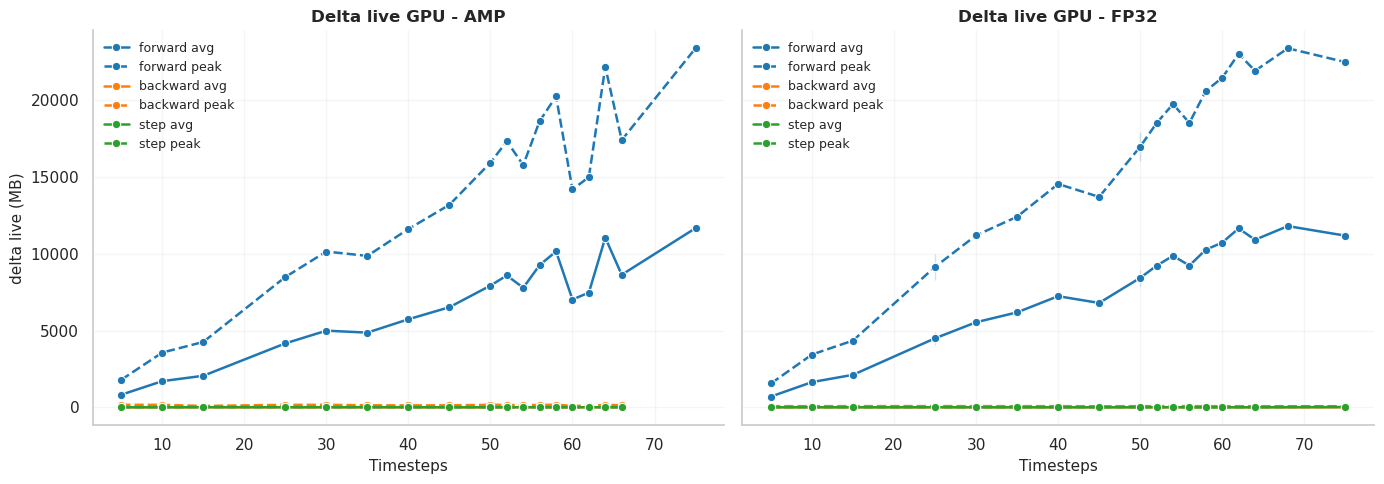

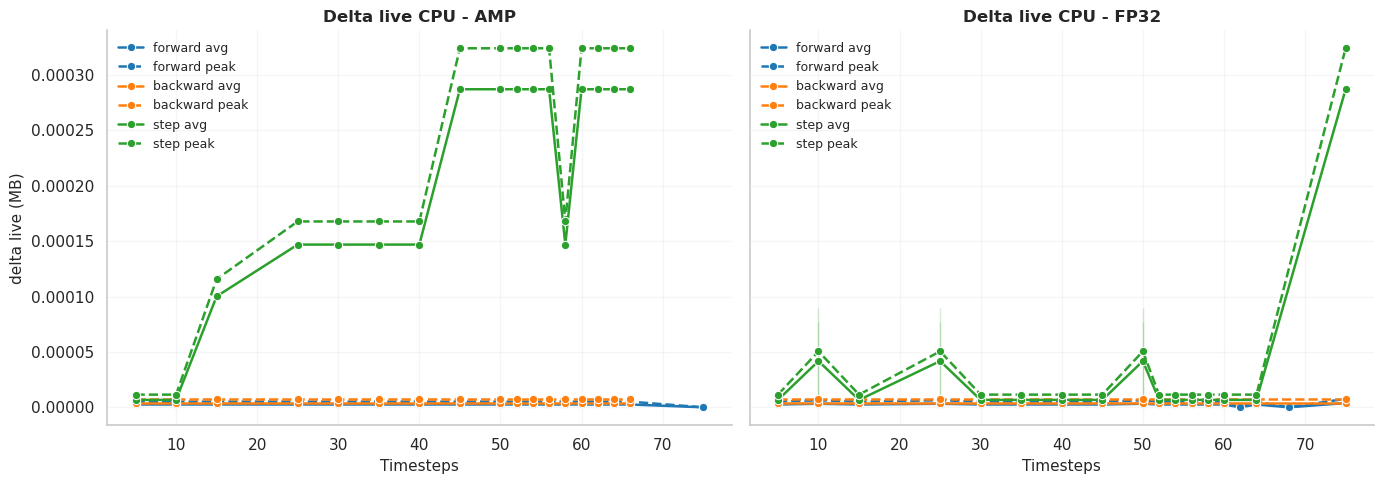

In [33]:
phase_defs = [
    ("train_forward", "forward"),
    ("train_backward", "backward"),
    ("train_step", "step"),
]
agg_defs = [("avg", "-", "avg"), ("peak", "--", "peak")]

def plot_delta(device_tag):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharex=True, sharey=True)
    for ax, amp in zip(axes, [True, False]):
        sub = df[df["use_amp"] == amp].sort_values("timesteps")

        for phase_key, phase_label in phase_defs:
            color = PHASE_COLORS[phase_key]
            for agg_key, ls, agg_label in agg_defs:
                col = f"{phase_key}_alloc_delta_{agg_key}_mb_{device_tag}"
                if col not in sub.columns or not sub[col].notna().any():
                    continue
                sns.lineplot(data=sub, x="timesteps", y=col, marker="o", linestyle=ls, linewidth=1.8,
                             color=color, label=f"{phase_label} {agg_label}", ax=ax)

        ax.set_title(f"Delta live {device_tag.upper()} - {AMP_LABELS[amp]}")
        ax.set_xlabel("Timesteps")
        ax.set_ylabel("delta live (MB)")
        h, _ = ax.get_legend_handles_labels()
        if h:
            ax.legend(loc="best", fontsize=9)

    plt.tight_layout()
    plt.show()

plot_delta("gpu")
plot_delta("cpu")


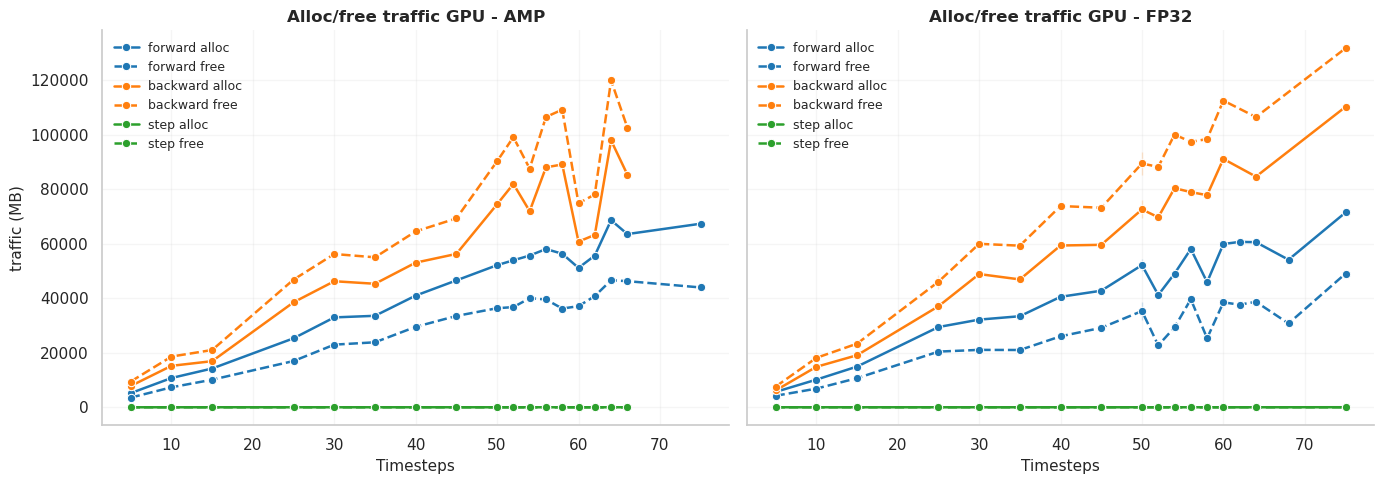

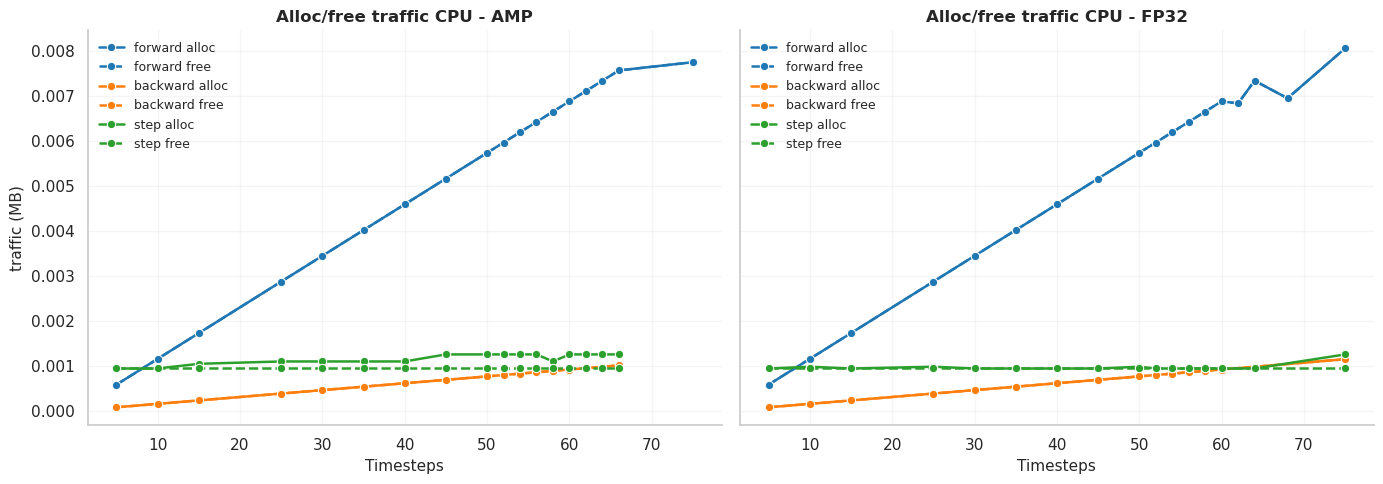

In [34]:
def plot_traffic(device_tag):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharex=True, sharey=True)
    for ax, amp in zip(axes, [True, False]):
        sub = df[df["use_amp"] == amp].sort_values("timesteps")

        for phase_key, phase_label in phase_defs:
            color = PHASE_COLORS[phase_key]
            alloc_col = f"{phase_key}_alloc_traffic_mb_{device_tag}"
            free_col = f"{phase_key}_free_traffic_mb_{device_tag}"

            if alloc_col in sub.columns and sub[alloc_col].notna().any():
                sns.lineplot(data=sub, x="timesteps", y=alloc_col, marker="o", linestyle="-", linewidth=1.8,
                             color=color, label=f"{phase_label} alloc", ax=ax)

            if free_col in sub.columns and sub[free_col].notna().any():
                sns.lineplot(data=sub, x="timesteps", y=free_col, marker="o", linestyle="--", linewidth=1.8,
                             color=color, label=f"{phase_label} free", ax=ax)

        ax.set_title(f"Alloc/free traffic {device_tag.upper()} - {AMP_LABELS[amp]}")
        ax.set_xlabel("Timesteps")
        ax.set_ylabel("traffic (MB)")
        h, _ = ax.get_legend_handles_labels()
        if h:
            ax.legend(loc="best", fontsize=9)

    plt.tight_layout()
    plt.show()

plot_traffic("gpu")
plot_traffic("cpu")


## Tablas


In [35]:
global_cols = [
    "run_name", "status", "timesteps", "batch_size", "use_amp", "oom_events",
    "max_alloc_gb_trace", "train_batch_s", "eval_no_f1_s", "eval_with_f1_s", "eval_f1_overhead_pct",
]
for c in global_cols:
    if c not in df.columns:
        df[c] = np.nan

display(df[global_cols].sort_values(["timesteps", "use_amp"], na_position="last"))


,run_name,status,timesteps,batch_size,use_amp,oom_events,max_alloc_gb_trace,train_batch_s,eval_no_f1_s,eval_with_f1_s,eval_f1_overhead_pct
0,sim90_bs4_pb4_5ts_fp32,ok,5,4,False,0.0,1.821651,0.167672,0.040949,0.095189,132.456028
1,sim90_bs4_pb4_5ts_amp,ok,5,4,True,0.0,1.906913,0.127686,0.053141,0.124070,133.473683
2,sim90_bs4_pb4_10ts,unknown,10,4,False,0.0,3.888391,0.394764,0.080430,0.171973,113.815965
3,sim90_bs4_pb4_10ts_fp32,ok,10,4,False,0.0,3.910101,0.203681,0.081862,0.170309,108.043695
4,sim90_bs4_pb4_10ts_amp,ok,10,4,True,0.0,3.776079,0.235426,0.094924,0.216110,127.666416
5,sim90_bs4_pb4_15ts_fp32,ok,15,4,False,0.0,5.329360,0.274095,0.112322,0.250471,122.993988
6,sim90_bs4_pb4_15ts_amp,ok,15,4,True,0.0,5.210321,0.540934,0.148398,0.273005,83.968450
7,sim90_bs4_pb4_25ts,unknown,25,4,False,0.0,9.403231,0.509018,0.167105,0.381575,128.344604
8,sim90_bs4_pb4_25ts_fp32,ok,25,4,False,0.0,10.022833,0.585557,0.188030,0.408659,117.336815
9,sim90_bs4_pb4_25ts_amp,ok,25,4,True,0.0,8.552274,0.614622,0.224221,0.451696,101.451358


In [36]:
phase_mem_cols = [
    "run_name", "timesteps", "use_amp",
    "train_forward_alloc_delta_avg_mb_gpu", "train_forward_alloc_delta_peak_mb_gpu",
    "train_backward_alloc_delta_avg_mb_gpu", "train_backward_alloc_delta_peak_mb_gpu",
    "train_step_alloc_delta_avg_mb_gpu", "train_step_alloc_delta_peak_mb_gpu",
    "train_forward_alloc_delta_avg_mb_cpu", "train_forward_alloc_delta_peak_mb_cpu",
    "train_backward_alloc_delta_avg_mb_cpu", "train_backward_alloc_delta_peak_mb_cpu",
    "train_step_alloc_delta_avg_mb_cpu", "train_step_alloc_delta_peak_mb_cpu",
    "train_forward_alloc_traffic_mb_gpu", "train_forward_free_traffic_mb_gpu",
    "train_backward_alloc_traffic_mb_gpu", "train_backward_free_traffic_mb_gpu",
    "train_step_alloc_traffic_mb_gpu", "train_step_free_traffic_mb_gpu",
    "train_forward_alloc_traffic_mb_cpu", "train_forward_free_traffic_mb_cpu",
    "train_backward_alloc_traffic_mb_cpu", "train_backward_free_traffic_mb_cpu",
    "train_step_alloc_traffic_mb_cpu", "train_step_free_traffic_mb_cpu",
]
for c in phase_mem_cols:
    if c not in df.columns:
        df[c] = np.nan

display(df[phase_mem_cols].sort_values(["timesteps", "use_amp"], na_position="last"))


,run_name,timesteps,use_amp,train_forward_alloc_delta_avg_mb_gpu,train_forward_alloc_delta_peak_mb_gpu,train_backward_alloc_delta_avg_mb_gpu,train_backward_alloc_delta_peak_mb_gpu,train_step_alloc_delta_avg_mb_gpu,train_step_alloc_delta_peak_mb_gpu,train_forward_alloc_delta_avg_mb_cpu,...,train_backward_alloc_traffic_mb_gpu,train_backward_free_traffic_mb_gpu,train_step_alloc_traffic_mb_gpu,train_step_free_traffic_mb_gpu,train_forward_alloc_traffic_mb_cpu,train_forward_free_traffic_mb_cpu,train_backward_alloc_traffic_mb_cpu,train_backward_free_traffic_mb_cpu,train_step_alloc_traffic_mb_cpu,train_step_free_traffic_mb_cpu
0,sim90_bs4_pb4_5ts_fp32,5,False,701.341352,1555.628906,0.411274,74.346517,5.657608,11.049805,0.000003,...,6185.441081,7592.227214,11.049805,11.049805,0.000580,0.000580,0.000076,0.000076,0.000938,0.000938
1,sim90_bs4_pb4_5ts_amp,5,True,818.876532,1792.610514,0.285104,161.813639,5.583212,11.540690,0.000003,...,7833.333822,9460.697917,11.543132,11.543132,0.000580,0.000580,0.000076,0.000076,0.000938,0.000938
2,sim90_bs4_pb4_10ts,10,False,1480.737574,3114.037964,0.219162,71.034668,8.953687,16.263672,0.000004,...,13098.007812,16058.884155,16.263672,10.886230,0.001152,0.001152,0.000153,0.000153,0.001017,0.000938
3,sim90_bs4_pb4_10ts_fp32,10,False,1804.915790,3767.381999,0.255133,76.250977,5.910335,11.532227,0.000003,...,16597.778483,20213.964518,11.532227,11.532227,0.001152,0.001152,0.000153,0.000153,0.000938,0.000938
4,sim90_bs4_pb4_10ts_amp,10,True,1703.547441,3567.045898,0.146769,163.297038,5.562819,11.469727,0.000003,...,15221.520996,18621.437012,11.472168,11.472168,0.001152,0.001152,0.000153,0.000153,0.000938,0.000938
5,sim90_bs4_pb4_15ts_fp32,15,False,2117.667063,4351.503906,0.137325,77.340332,5.549294,10.862142,0.000003,...,19108.436686,23348.699056,10.862142,10.862142,0.001724,0.001724,0.000229,0.000229,0.000938,0.000938
6,sim90_bs4_pb4_15ts_amp,15,True,2054.747129,4259.978027,0.075621,87.364421,10.154995,18.696126,0.000003,...,16927.540039,21025.836263,18.698568,10.854655,0.001724,0.001724,0.000229,0.000229,0.001043,0.000938
7,sim90_bs4_pb4_25ts,25,False,4079.723037,8315.990234,0.091803,75.821411,8.963204,16.213013,0.000004,...,35257.878174,43423.598145,16.213013,10.652344,0.002869,0.002869,0.000381,0.000381,0.001017,0.000938
8,sim90_bs4_pb4_25ts_fp32,25,False,4915.822123,9993.452311,0.105127,82.397135,5.584020,10.995768,0.000003,...,38887.552734,48728.589355,10.995768,10.995768,0.002869,0.002869,0.000381,0.000381,0.000938,0.000938
9,sim90_bs4_pb4_25ts_amp,25,True,4166.166387,8490.504232,0.059354,162.543294,7.992016,14.551432,0.000003,...,38533.156413,46857.410807,14.553385,7.164714,0.002869,0.002869,0.000381,0.000381,0.001095,0.000938
